## 1. Configurações Iniciais e Algoritmos de Busca

Nesta célula, importamos as bibliotecas necessárias para a análise (como Pandas e Matplotlib) e estruturamos as classes base do projeto. Aqui também estão implementados os 6 algoritmos de busca clássica que vamos testar e comparar no labirinto:

1. **Busca em Largura (BFS)** — Cega e ótima para custo uniforme.
2. **Busca em Profundidade (DFS)** — Cega e focada em memória, não ótima.
3. **Busca de Custo Uniforme (UCS)** — Cega e ótima para qualquer custo acumulado.
4. **Greedy Best-First (Gulosa)** — Informada, rápida, mas míope.
5. **Busca A*** — Informada e ótima (usando a Heurística de Manhattan).
6. **Busca IDA*** — Versão iterativa do A* focada em economia de memória RAM (esta é a que o professor mandou para evitar estouro de pilha e conseguir rodar o algoritmo corretamente).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Set
from collections import deque
import heapq
import itertools
import math
import os

Estado = Tuple[int, int]

@dataclass
class No:
    estado: Estado
    pai: Optional['No'] = None
    acao: Optional[str] = None
    g: float = 0.0

@dataclass
class ResultadoBusca:
    algoritmo: str
    encontrado: bool
    caminho: List[Estado]
    acoes: List[str]
    nos_explorados: int
    nos_expandidos: int
    estados_explorados: List[Estado]

    @property
    def tamanho_caminho(self) -> Optional[int]:
        return len(self.acoes) if self.encontrado else None

class LabirintoBusca:
    def __init__(self, filename: str):
        with open(filename, encoding='utf-8') as f:
            contents = f.read()

        if contents.count('A') != 1:
            raise ValueError('O labirinto deve ter exatamente um ponto inicial A.')
        if contents.count('B') != 1:
            raise ValueError('O labirinto deve ter exatamente um objetivo B.')

        linhas = contents.splitlines()
        self.altura = len(linhas)
        self.largura = max(len(linha) for linha in linhas)
        self.paredes = []

        for i in range(self.altura):
            row = []
            for j in range(self.largura):
                char = linhas[i][j] if j < len(linhas[i]) else ' '
                if char == 'A':
                    self.inicio = (i, j)
                    row.append(False)
                elif char == 'B':
                    self.objetivo = (i, j)
                    row.append(False)
                elif char == ' ':
                    row.append(False)
                else:
                    row.append(True)
            self.paredes.append(row)

    def vizinhos(self, estado: Estado):
        linha, coluna = estado
        candidatos = [
            ('up',    (linha - 1, coluna)),
            ('down',  (linha + 1, coluna)),
            ('left',  (linha, coluna - 1)),
            ('right', (linha, coluna + 1)),
        ]
        resultado = []
        for acao, (l, c) in candidatos:
            if 0 <= l < self.altura and 0 <= c < self.largura and not self.paredes[l][c]:
                resultado.append((acao, (l, c), 1.0))
        return resultado

    def h(self, estado: Estado) -> float:
        """Heurística de Manhattan para movimentos ortogonais com custo unitário."""
        return abs(estado[0] - self.objetivo[0]) + abs(estado[1] - self.objetivo[1])

    @staticmethod
    def reconstruir(no: No):
        estados = []
        acoes = []
        atual = no
        while atual.pai is not None:
            estados.append(atual.estado)
            acoes.append(atual.acao)
            atual = atual.pai
        estados.reverse()
        acoes.reverse()
        return estados, acoes

    def busca_largura(self) -> ResultadoBusca:
        inicio = No(self.inicio)
        fronteira = deque([inicio])
        em_fronteira = {self.inicio}
        explorados: Set[Estado] = set()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0

        while fronteira:
            no = fronteira.popleft()
            em_fronteira.remove(no.estado)
            nos_explorados += 1
            ordem_explorados.append(no.estado)

            if no.estado == self.objetivo:
                caminho, acoes = self.reconstruir(no)
                return ResultadoBusca('Busca em Largura (BFS)', True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados)

            explorados.add(no.estado)
            nos_expandidos += 1

            for acao, estado, custo in self.vizinhos(no.estado):
                if estado not in explorados and estado not in em_fronteira:
                    filho = No(estado=estado, pai=no, acao=acao, g=no.g + custo)
                    fronteira.append(filho)
                    em_fronteira.add(estado)

        return ResultadoBusca('Busca em Largura (BFS)', False, [], [], nos_explorados, nos_expandidos, ordem_explorados)

    def busca_profundidade(self) -> ResultadoBusca:
        inicio = No(self.inicio)
        fronteira = [inicio]
        em_fronteira = {self.inicio}
        explorados: Set[Estado] = set()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0

        while fronteira:
            no = fronteira.pop()
            em_fronteira.remove(no.estado)
            nos_explorados += 1
            ordem_explorados.append(no.estado)

            if no.estado == self.objetivo:
                caminho, acoes = self.reconstruir(no)
                return ResultadoBusca('Busca em Profundidade (DFS)', True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados)

            explorados.add(no.estado)
            nos_expandidos += 1

            for acao, estado, custo in self.vizinhos(no.estado):
                if estado not in explorados and estado not in em_fronteira:
                    filho = No(estado=estado, pai=no, acao=acao, g=no.g + custo)
                    fronteira.append(filho)
                    em_fronteira.add(estado)

        return ResultadoBusca('Busca em Profundidade (DFS)', False, [], [], nos_explorados, nos_expandidos, ordem_explorados)

    def busca_prioridade(self, nome: str, funcao_prioridade) -> ResultadoBusca:
        contador = itertools.count()
        inicio = No(self.inicio, g=0.0)
        fronteira = []
        heapq.heappush(fronteira, (funcao_prioridade(inicio), next(contador), inicio))
        melhor_g: Dict[Estado, float] = {self.inicio: 0.0}
        fechados: Set[Estado] = set()
        ordem_explorados: List[Estado] = []
        nos_explorados = 0
        nos_expandidos = 0

        while fronteira:
            _, _, no = heapq.heappop(fronteira)

            if no.estado in fechados:
                continue

            nos_explorados += 1
            ordem_explorados.append(no.estado)

            if no.estado == self.objetivo:
                caminho, acoes = self.reconstruir(no)
                return ResultadoBusca(nome, True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados)

            fechados.add(no.estado)
            nos_expandidos += 1

            for acao, estado, custo in self.vizinhos(no.estado):
                novo_g = no.g + custo
                if estado in fechados:
                    continue
                if novo_g < melhor_g.get(estado, math.inf):
                    filho = No(estado=estado, pai=no, acao=acao, g=novo_g)
                    melhor_g[estado] = novo_g
                    heapq.heappush(fronteira, (funcao_prioridade(filho), next(contador), filho))

        return ResultadoBusca(nome, False, [], [], nos_explorados, nos_expandidos, ordem_explorados)

    def busca_custo_uniforme(self) -> ResultadoBusca:
        return self.busca_prioridade(
            'Busca de Custo Uniforme (UCS)',
            lambda no: no.g
        )

    def busca_gulosa(self) -> ResultadoBusca:
        return self.busca_prioridade(
            'Greedy Best-First Search',
            lambda no: self.h(no.estado)
        )

    def busca_weighted_astar(self, peso: float = 1.0) -> ResultadoBusca:
        nome_algoritmo = 'A* (A-Estrela)' if peso == 1.0 else f'Weighted A* (w={peso})'
        return self.busca_prioridade(
            nome_algoritmo,
            lambda no: no.g + peso * self.h(no.estado)
        )

    def busca_idastar(self, max_iteracoes: int = 10_000) -> ResultadoBusca:
        nos_explorados = 0
        nos_expandidos = 0
        ordem_explorados: List[Estado] = []

        inicio = No(self.inicio, g=0.0)
        limite = self.h(self.inicio)

        def dfs_limitado(no: No, limite_atual: float, caminho_atual: Set[Estado], melhor_g_iteracao: Dict[Estado, float]):
            nonlocal nos_explorados, nos_expandidos, ordem_explorados

            nos_explorados += 1
            ordem_explorados.append(no.estado)
            f = no.g + self.h(no.estado)

            if f > limite_atual:
                return f, None
            if no.estado == self.objetivo:
                return "FOUND", no

            nos_expandidos += 1
            menor_proximo_limite = math.inf

            vizinhos_ordenados = sorted(
                self.vizinhos(no.estado),
                key=lambda item: no.g + item[2] + self.h(item[1])
            )

            for acao, estado, custo in vizinhos_ordenados:
                if estado in caminho_atual:
                    continue

                novo_g = no.g + custo
                if novo_g >= melhor_g_iteracao.get(estado, math.inf):
                    continue

                melhor_g_iteracao[estado] = novo_g
                filho = No(estado=estado, pai=no, acao=acao, g=novo_g)

                caminho_atual.add(estado)
                temp, solucao = dfs_limitado(filho, limite_atual, caminho_atual, melhor_g_iteracao)
                caminho_atual.remove(estado)

                if temp == "FOUND":
                    return "FOUND", solucao
                if temp < menor_proximo_limite:
                    menor_proximo_limite = temp

            return menor_proximo_limite, None

        for _ in range(max_iteracoes):
            melhor_g_iteracao = {self.inicio: 0.0}
            temp, solucao = dfs_limitado(inicio, limite, {self.inicio}, melhor_g_iteracao)

            if temp == "FOUND":
                caminho, acoes = self.reconstruir(solucao)
                return ResultadoBusca("IDA*", True, caminho, acoes, nos_explorados, nos_expandidos, ordem_explorados)
            if temp == math.inf:
                return ResultadoBusca("IDA*", False, [], [], nos_explorados, nos_expandidos, ordem_explorados)

            limite = temp

        raise RuntimeError("IDA* interrompido: número máximo de iterações atingido.")

## 2. Execução dos Experimentos, Gráficos e Exportação

Esta é a célula de execução prática. O script carrega o arquivo do labirinto, roda todos os algoritmos em lote de forma sequencial e coleta as métricas de desempenho. 

Ao final da execução, o código faz três coisas automaticamente:
* Exibe uma **tabela comparativa** com os resultados na tela (Tamanho do Caminho, Nós Expandidos e Nós Explorados).
* Salva esses dados brutos no arquivo **`resultados_semana1.csv`**, conforme foi exigido no trabalho.
* Plota os **gráficos de barras** para facilitar a nossa análise visual e crítica do comportamento de cada algoritmo.

Executando algoritmos no lab_oficial.txt...

--- TABELA DE RESULTADOS ---


,Labirinto,Algoritmo,Tamanho do Caminho,Nós Expandidos,Nós Explorados
0,lab_oficial.txt,Busca em Largura (BFS),253,3148,3149
1,lab_oficial.txt,Busca em Profundidade (DFS),283,703,704
2,lab_oficial.txt,Busca de Custo Uniforme (UCS),253,3148,3149
3,lab_oficial.txt,Greedy Best-First Search,253,1099,1100
4,lab_oficial.txt,A* (A-Estrela),253,1826,1827
5,lab_oficial.txt,IDA*,253,344522,360869



Resultados exportados com sucesso para: resultados_semana1.csv


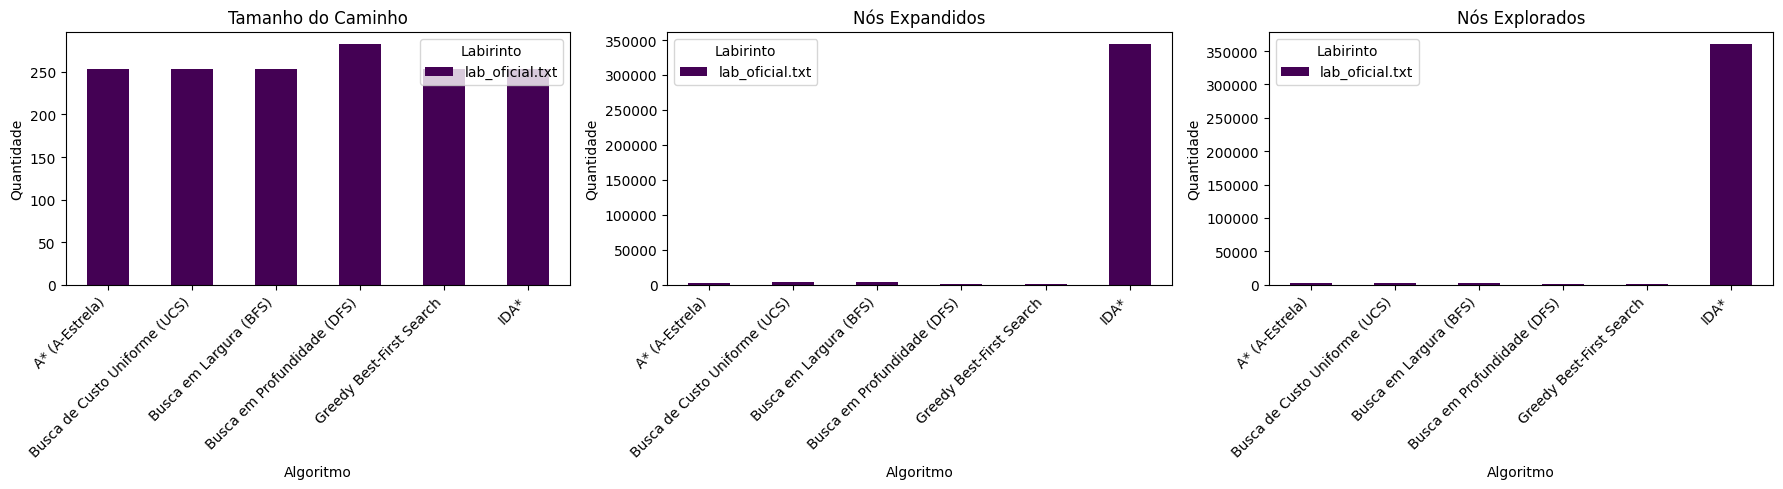

In [3]:

arquivos_labirinto = ['lab_oficial.txt'] 
resultados_gerais = []

for arq in arquivos_labirinto:
    if not os.path.exists(arq):
        print(f"Aviso: Arquivo {arq} não encontrado. Pulando...")
        continue
        
    print(f"Executando algoritmos no {arq}...")
    lab = LabirintoBusca(arq)
    
    buscas = [
        lab.busca_largura(),
        lab.busca_profundidade(),
        lab.busca_custo_uniforme(),
        lab.busca_gulosa(),
        lab.busca_weighted_astar(1.0), # Peso 1.0 para agir como A* puro
        lab.busca_idastar()
    ]
    
    for r in buscas:
        resultados_gerais.append({
            'Labirinto': arq,
            'Algoritmo': r.algoritmo,
            'Tamanho do Caminho': r.tamanho_caminho if r.encontrado else 0,
            'Nós Expandidos': r.nos_expandidos,
            'Nós Explorados': r.nos_explorados
        })

if resultados_gerais:
    df_resultados = pd.DataFrame(resultados_gerais)
    print("\n--- TABELA DE RESULTADOS ---")
    display(df_resultados) # O display deixa a tabela bonita no Jupyter

    csv_filename = 'resultados_semana1.csv'
    df_resultados.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"\nResultados exportados com sucesso para: {csv_filename}")

    # Gerar gráficos comparativos
    metricas = ['Tamanho do Caminho', 'Nós Expandidos', 'Nós Explorados']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, metrica in enumerate(metricas):
        df_pivot = df_resultados.pivot(index='Algoritmo', columns='Labirinto', values=metrica)
        df_pivot.plot(kind='bar', ax=axes[i], title=metrica, colormap='viridis')
        axes[i].set_ylabel('Quantidade')
        axes[i].set_xticklabels(df_pivot.index, rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum resultado processado. Verifique se os arquivos de labirinto existem.")